# 518880 `1tick -> 2tick` 形成机制与 `spread=2` 状态分型

这个 notebook 只读取 `data/spread2_transition_regime/` 下已经生成的 CSV，
不直接加载 snapshot。

展示内容：

- `1tick -> 2tick` 转移机制占比
- 转移前后 event study
- `spread=2` episode 的持续时间/收益特征
- `spread=2` 状态分型结果


In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display

plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 200)
pd.set_option('display.float_format', lambda x: f'{x:,.4f}')

BASE_DIR = Path.cwd().resolve()
if not (BASE_DIR / 'data').exists():
    if (BASE_DIR.parent / 'data').exists():
        BASE_DIR = BASE_DIR.parent
    elif (BASE_DIR / '518880' / 'data').exists():
        BASE_DIR = BASE_DIR / '518880'
DATA_DIR = BASE_DIR / 'data' / 'spread2_transition_regime'

def read_csv(name: str) -> pd.DataFrame:
    path = DATA_DIR / f'{name}.csv'
    if not path.exists():
        raise FileNotFoundError(f'missing csv: {path}')
    return pd.read_csv(path)

overview = read_csv('overview')
transition_summary = read_csv('transition_summary')
transition_by_time = read_csv('transition_by_time')
event_study = read_csv('transition_event_study')
episode_samples = read_csv('episode_samples')
cluster_summary = read_csv('episode_cluster_summary')

display(DATA_DIR)


PosixPath('/home/jovyan/work/tactics_demo/518880/data/spread2_transition_regime')

## 1. 如何刷新数据

如果要重新生成 CSV，在 notebook 同目录执行：

```bash
python3.13 ../code/spread2_transition_regime.py
```

当前环境里 `base_tool` 是 `cpython-313` 扩展，所以通常需要 Python 3.13。

In [2]:
display(overview)
display(transition_summary)

row = overview.iloc[0]
text = f'''
### 样本概览

- 交易日数: `{int(row['trade_days'])}`
- 常规时段快照数: `{int(row['panel_rows']):,}`
- `spread=2` 占比: `{row['spread2_ratio']:.2%}`
- `1tick -> 2tick` 转移次数: `{int(row['spread12_entries']):,}`
- `spread=2` episode 数: `{int(row['spread2_episodes']):,}`
'''
display(Markdown(text))


,trade_days,panel_rows,spread1_rows,spread2_rows,spread12_entries,spread2_episodes,spread2_ratio
0,49,705331,653455,45599,30830,32627,0.0646


,transition_mechanism,samples,trade_days,avg_entry_l1_imbalance,avg_entry_l3_imbalance,avg_entry_l1_depth,avg_entry_l5_depth,avg_active_turnover,avg_net_active_vol,avg_trade_count_delta,avg_mid_move_half_tick,sample_share
0,bid_retreat,12766,49,0.0242,0.0152,"408,318.5042","3,062,149.6013","919,127.8243","-38,905.5175",21.4158,-1.0000,0.4141
1,ask_retreat,12402,49,-0.0077,0.0127,"412,865.2446","3,104,127.4380","974,659.2675","39,425.1258",19.8054,1.0000,0.4023
2,both_up_ask_faster,2915,49,-0.1131,-0.0014,"246,036.5259","2,247,992.8182","2,271,450.1972","129,727.5204",38.0875,3.7190,0.0946
3,both_down_bid_faster,2747,48,0.1118,0.0197,"259,937.8082","2,257,772.3771","2,380,455.0518","-136,468.6938",56.2610,-3.7288,0.0891



### 样本概览

- 交易日数: `49`
- 常规时段快照数: `705,331`
- `spread=2` 占比: `6.46%`
- `1tick -> 2tick` 转移次数: `30,830`
- `spread=2` episode 数: `32,627`


### 如何理解上面的结果

- `overview` 是样本边界检查。先确认交易日数、快照数、`spread=2` 占比是否和你的研究直觉一致。
- `spread12_entries` 表示从 `1tick` 切到 `2tick` 的次数。后面所有“形成机制”的统计，分母基本都是这批 entry。
- `spread2_episodes` 把连续多秒的 `spread=2` 合并成一个状态段。它通常会小于 `spread2` 总秒数很多，因为一个状态会持续多秒。
- `transition_summary` 是第一张核心表。`sample_share` 看哪种形成机制最常见；`avg_entry_l1_imbalance` 看 widening 时盘口偏向哪边；`avg_entry_l1_depth` / `avg_entry_l5_depth` 看 widening 出现时盘口是薄还是厚；`avg_active_turnover` / `avg_net_active_vol` 看 widening 前后是否伴随主动成交冲击。
- 如果某个机制 `sample_share` 很高，但 `avg_mid_move_half_tick` 接近 0，通常说明它更像“无序 widening”而不是带明确方向信息的 widening。

## 2. `1tick -> 2tick` 如何形成

先看转移机制占比，再看它们在盘中不同时段的分布。

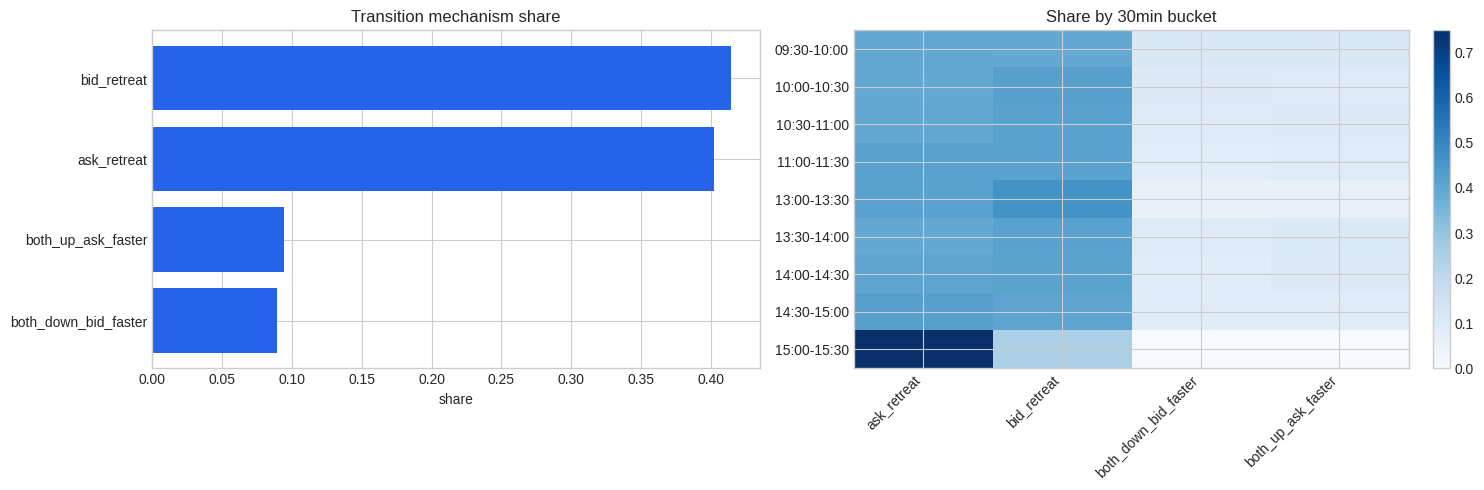

,time_bucket_30m,transition_mechanism,samples,avg_entry_l1_imbalance,avg_entry_l1_depth,avg_active_turnover,bucket_share
0,09:30-10:00,ask_retreat,1991,-0.0312,"433,278.8669","1,342,763.1479",0.3943
1,09:30-10:00,bid_retreat,1972,0.0154,"440,660.2079","1,243,207.2971",0.3906
3,09:30-10:00,both_up_ask_faster,552,-0.1577,"274,370.7120","2,590,169.9859",0.1093
2,09:30-10:00,both_down_bid_faster,534,0.1473,"261,462.7978","2,657,350.9422",0.1058
5,10:00-10:30,bid_retreat,1524,0.0194,"385,909.1352","919,364.5021",0.4203
4,10:00-10:30,ask_retreat,1419,-0.0406,"372,627.5300","943,177.2216",0.3913
6,10:00-10:30,both_down_bid_faster,350,0.1589,"259,615.4286","2,449,636.9491",0.0965
7,10:00-10:30,both_up_ask_faster,333,-0.1485,"231,989.3694","2,196,417.4929",0.0918
9,10:30-11:00,bid_retreat,1659,0.0159,"392,246.8481","790,374.8189",0.4143
8,10:30-11:00,ask_retreat,1576,0.0159,"393,945.0114","816,739.0384",0.3936


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

plot_df = transition_summary.sort_values('samples', ascending=True)
axes[0].barh(plot_df['transition_mechanism'], plot_df['sample_share'], color='#2563eb')
axes[0].set_title('Transition mechanism share')
axes[0].set_xlabel('share')

pivot_share = transition_by_time.pivot(index='time_bucket_30m', columns='transition_mechanism', values='bucket_share').fillna(0)
im = axes[1].imshow(pivot_share.values, aspect='auto', cmap='Blues')
axes[1].set_title('Share by 30min bucket')
axes[1].set_xticks(range(len(pivot_share.columns)))
axes[1].set_xticklabels(pivot_share.columns, rotation=45, ha='right')
axes[1].set_yticks(range(len(pivot_share.index)))
axes[1].set_yticklabels(pivot_share.index)
fig.colorbar(im, ax=axes[1], fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()

display(transition_by_time.sort_values(['time_bucket_30m', 'samples'], ascending=[True, False]).head(20))


### 如何理解上面的结果

- 左图回答的是：`1tick -> 2tick` 最常见是怎么发生的。若 `ask_retreat` 最大，说明更多是卖一后撤导致 spread 打开；若 `bid_retreat` 最大，则更多是买一撤退。
- `both_widen` 如果占比不低，往往说明不是单边撤单，而是两边同时变差，这更像流动性整体变薄或同步重定价。
- 右图热力图回答的是：这些机制是否有明显时段性。比如早盘更常见 `both_widen`，午后更常见 `ask_retreat`，那说明 `2tick` 的形成并不是同一种微观结构过程。
- 如果某个机制全天都均匀出现，它更像“背景噪声”；如果只集中在少数时段，它更可能和开盘、午后、收盘前的特定流动性环境有关。
- 你可以重点盯两个问题：
  1. 主导机制是否单一。如果很单一，后续分型重点放在这个机制内部。
  2. 主导机制是否有时段切换。如果有，后续建模最好把时段作为条件，不要把全天混成一个分布。

## 3. 转移前后 event study

这里把每次 `1tick -> 2tick` 发生的前 `5s`、后 `10s` 做横向平均。重点看：

- `l1 imbalance`
- `l1 depth`
- `active turnover`
- 当秒 `mid` 变化


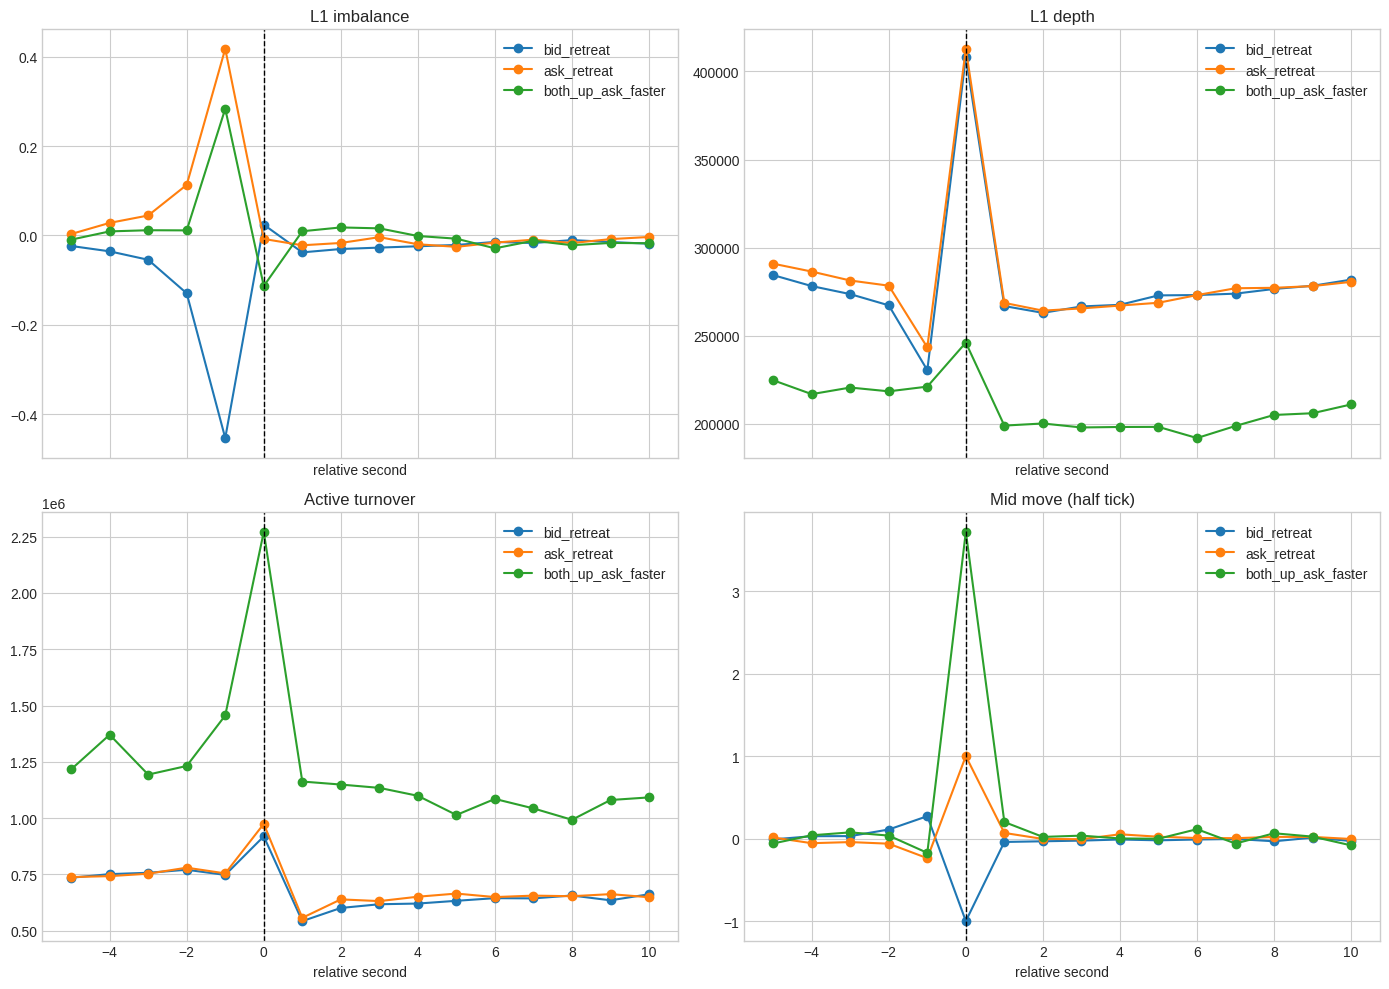

,transition_mechanism,relative_second,samples,spread_ticks_mean,mid_move_half_tick_mean,l1_imbalance_mean,l1_depth_mean,l5_depth_mean,active_turnover_mean,net_active_vol_mean,trade_count_delta_mean
0,ask_retreat,-5,12399,1.1727,0.0139,0.0033,"290,849.4262","2,939,849.9598","738,352.7247","-2,629.9886",17.2059
1,ask_retreat,-4,12400,1.1721,-0.0552,0.0282,"286,371.9343","2,932,593.4535","742,520.7891","-4,012.4486",17.6886
2,ask_retreat,-3,12402,1.1710,-0.0418,0.0448,"281,296.0682","2,928,401.7537","753,323.9419","-2,516.1455",17.5585
3,ask_retreat,-2,12402,1.1688,-0.0613,0.1134,"278,361.6388","2,918,741.5703","780,050.8155",-545.3566,17.5590
4,ask_retreat,-1,12402,1.0000,-0.2368,0.4181,"243,335.3139","2,870,265.9185","754,686.1533","3,070.8643",17.1787
5,ask_retreat,0,12402,2.0000,1.0000,-0.0077,"412,865.2446","3,104,127.4380","974,659.2675","39,425.1258",19.8054
6,ask_retreat,1,12399,1.2749,0.0692,-0.0219,"268,579.9068","2,926,390.8640","557,333.9822","-3,190.8156",13.5475
7,ask_retreat,2,12398,1.2112,-0.0038,-0.0167,"264,182.1065","2,915,074.0219","639,246.1405","-2,597.7333",14.9427
8,ask_retreat,3,12397,1.1817,-0.0069,-0.0037,"265,451.7578","2,916,456.1339","631,618.0364","-2,028.3898",14.7310
9,ask_retreat,4,12396,1.1705,0.0525,-0.0197,"267,066.1992","2,915,743.2541","651,137.9887",111.8875,15.3200


In [4]:
top_mechanisms = transition_summary.head(3)['transition_mechanism'].tolist()
plot_event = event_study[event_study['transition_mechanism'].isin(top_mechanisms)].copy()

fig, axes = plt.subplots(2, 2, figsize=(14, 10), sharex=True)
metric_map = {
    'l1_imbalance_mean': 'L1 imbalance',
    'l1_depth_mean': 'L1 depth',
    'active_turnover_mean': 'Active turnover',
    'mid_move_half_tick_mean': 'Mid move (half tick)',
}

for ax, (metric, title) in zip(axes.ravel(), metric_map.items()):
    for mechanism in top_mechanisms:
        temp = plot_event[plot_event['transition_mechanism'] == mechanism]
        ax.plot(temp['relative_second'], temp[metric], marker='o', label=mechanism)
    ax.axvline(0, color='black', linestyle='--', linewidth=1)
    ax.set_title(title)
    ax.set_xlabel('relative second')
    ax.legend()

plt.tight_layout()
plt.show()

display(plot_event.head(30))


### 如何理解上面的结果

- `relative_second = 0` 是 spread 从 `1tick` 变成 `2tick` 的那一秒。先看 0 点有没有明显跳变，再看 0 点前是否有提前累积。
- `L1 imbalance` 如果在 0 点前就持续偏一边，说明 widening 不是完全随机，而是先有一侧压力，后出现盘口后撤。
- `L1 depth` 如果在 0 点前明显下降，通常表示盘口先变薄，再进入 `2tick`。这更像“流动性抽走”。如果 0 点时突然下降，则更像瞬时撤单事件。
- `Active turnover` 如果在 0 点附近冲高，说明 widening 和主动成交冲击相关；如果很平，说明更多是挂单侧自己撤退，而不是被成交打穿。
- `mid_move_half_tick_mean` 最关键。若进入 `2tick` 后几秒仍明显偏正或偏负，说明该形成机制自带短期方向延续；若很快回到 0 附近，说明它只带来更大的后续波动，但方向并不稳定。
- 你的原始判断“`spread=2` 后移动更大但方向弱”，通常会在这里体现成：
  1. `active_turnover` 和 `depth` 明显异常。
  2. `mid_move_half_tick_mean` 的绝对值不小，但不同机制的正负会互相抵消。
- 如果不同机制在 event study 中形状差很多，后续不要再把所有 `spread=2` 合并研究。

## 4. `spread=2` 是否存在不同种类

脚本把连续的 `spread=2` 区间视作一个 episode，然后用以下信息做聚类：

- entry 时的 `imbalance/depth`
- entry 前 3 秒主动成交
- episode 持续时间
- episode 内主动成交和 `mid` 波动
- entry 是偏 `ask_retreat` 还是偏 `bid_retreat`


,cluster_id,samples,share,duration_mean,duration_median,entry_l1_imbalance_mean,entry_l1_depth_mean,episode_active_turnover_mean,episode_mid_ret_abs_tick_mean,up_exit_ratio,down_exit_ratio,mechanism_share_ask_retreat,mechanism_share_bid_retreat,mechanism_share_both_down_bid_faster,mechanism_share_both_up_ask_faster,mechanism_share_other_reprice,mechanism_share_start_of_day,cluster_label,entry_l1_imbalance,entry_l3_imbalance,entry_l5_imbalance,entry_l1_depth,entry_l5_depth,duration_seconds,pre_active_turnover_3s,pre_net_active_vol_3s,episode_active_turnover,episode_net_active_vol,episode_abs_mid_move_half_tick_mean,entry_side_code
0,0,10171,0.3117,1.4499,1.0000,0.2833,"264,827.5388","1,835,093.1970",0.1603,0.5660,0.4315,0.6027,0.0057,0.1612,0.1626,0.0673,0.0005,ask_retreat_bid_pressure_thick_short,0.2828,0.2762,0.1981,"264,799.8721","2,459,239.1905",1.4502,"3,160,553.3067",-569.7833,"1,834,888.4438","20,827.3630",1.7604,0.7926
1,1,3842,0.1178,1.2233,1.0000,-0.0056,"1,025,957.3300","1,303,305.9193",0.0115,0.5211,0.4789,0.5458,0.4053,0.0232,0.0208,0.0049,0.0000,ask_retreat_balanced_thick_short,-0.0057,-0.0158,-0.0189,"1,026,327.0805","5,383,284.6754",1.2230,"1,893,721.5864","-4,931.0003","1,302,809.7412","15,351.9367",1.0057,0.1650
2,2,8930,0.2737,1.3261,1.0000,0.1595,"326,586.1656","1,025,459.4304",0.0560,0.5240,0.4753,0.0000,0.9993,0.0007,0.0000,0.0000,0.0000,bid_retreat_balanced_thick_short,0.1588,0.1352,0.0904,"326,617.9780","2,824,471.8337",1.3253,"2,104,091.6163","-5,688.9840","1,024,237.3254","-43,412.7596",0.9240,-0.9990
3,3,9684,0.2968,1.4777,1.0000,-0.4261,"261,206.8302","1,656,169.7187",0.1564,0.4286,0.5694,0.4311,0.2300,0.1271,0.1448,0.0670,0.0000,ask_retreat_ask_pressure_thick_short,-0.4264,-0.3689,-0.2434,"261,211.0168","2,362,182.0567",1.4784,"3,365,370.1667","-10,675.8934","1,658,146.7447","10,086.9139",1.5994,0.3719


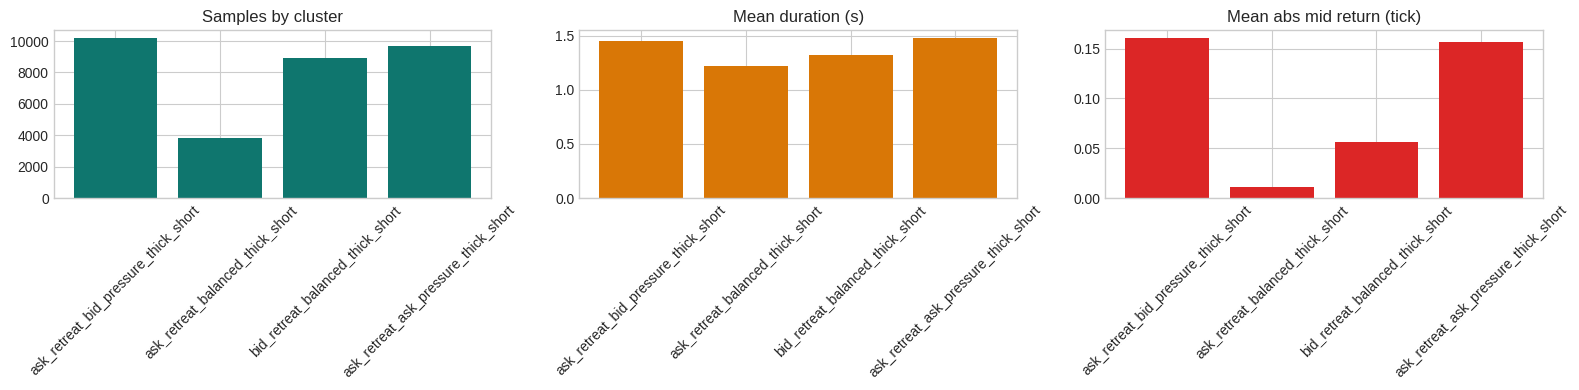

In [5]:
display(cluster_summary)

if not cluster_summary.empty and 'cluster_id' in cluster_summary.columns:
    fig, axes = plt.subplots(1, 3, figsize=(16, 4))
    axes[0].bar(cluster_summary['cluster_label'], cluster_summary['samples'], color='#0f766e')
    axes[0].set_title('Samples by cluster')
    axes[0].tick_params(axis='x', rotation=45)

    axes[1].bar(cluster_summary['cluster_label'], cluster_summary['duration_mean'], color='#d97706')
    axes[1].set_title('Mean duration (s)')
    axes[1].tick_params(axis='x', rotation=45)

    axes[2].bar(cluster_summary['cluster_label'], cluster_summary['episode_mid_ret_abs_tick_mean'], color='#dc2626')
    axes[2].set_title('Mean abs mid return (tick)')
    axes[2].tick_params(axis='x', rotation=45)

    plt.tight_layout()
    plt.show()


### 如何理解上面的结果

- `cluster_summary` 不是预测结果，而是“把 `spread=2` 拆成几类状态”的描述表。先看 `samples/share`，确认这些 cluster 不是极小众噪声。
- `cluster_label` 是我根据聚类中心自动起的名字，重点读其中四块信息：
  1. `ask_retreat / bid_retreat / mixed` 看 entry 主要来自哪种 widening 方式。
  2. `bid_pressure / ask_pressure / balanced` 看 entry 时盘口偏向。
  3. `thin / middepth / thick` 看 entry 时盘口厚薄。
  4. `short / medium / long` 看 `spread=2` 持续时间。
- `duration_mean` 高但 `episode_mid_ret_abs_tick_mean` 也高，说明这是“持续较久且不稳定”的 2tick 状态；如果持续时间短但绝对收益也高，更像瞬时冲击型 widening。
- `up_exit_ratio` / `down_exit_ratio` 看 episode 结束后紧接着那一秒，价格更容易朝哪边继续。如果两者接近，说明这个 cluster 主要解释的是波动状态而不是方向状态。
- `mechanism_share_*` 列非常有用。它告诉你某个 cluster 本质上是不是由某一种进入机制主导。如果是，说明“形成方式”本身就是最强的分型轴。

In [6]:
cols = [
    'spread2_episode_id',
    'trade_ymd',
    'entry_time',
    'transition_mechanism',
    'cluster_label',
    'duration_seconds',
    'entry_l1_imbalance',
    'entry_l1_depth',
    'episode_active_turnover',
    'episode_mid_ret_tick',
    'exit_next_mechanism',
]

sample_view = episode_samples[cols].copy()
sample_view = sample_view.sort_values(['cluster_label', 'duration_seconds', 'episode_active_turnover'], ascending=[True, False, False])
display(sample_view.head(30))


,spread2_episode_id,trade_ymd,entry_time,transition_mechanism,cluster_label,duration_seconds,entry_l1_imbalance,entry_l1_depth,episode_active_turnover,episode_mid_ret_tick,exit_next_mechanism
31515,20260417_00314,20260417,13:32:40,ask_retreat,ask_retreat_ask_pressure_thick_short,19,-0.2858,"222,900.0000","3,046,495.9000",0.0000,other_reprice
17312,20260303_00716,20260303,13:45:33,both_down_bid_faster,ask_retreat_ask_pressure_thick_short,15,-0.9360,"50,000.0000","3,282,719.2000",2.0000,both_up_ask_faster
5945,20260119_00109,20260119,10:29:21,ask_retreat,ask_retreat_ask_pressure_thick_short,11,-0.6686,"429,700.0000","2,743,603.5000",-1.0000,other_reprice
32165,20260423_00128,20260423,10:16:09,other_reprice,ask_retreat_ask_pressure_thick_short,10,0.2687,"13,400.0000","4,831,447.6000",1.0000,other_reprice
25390,20260327_00462,20260327,11:12:00,ask_retreat,ask_retreat_ask_pressure_thick_short,10,-0.6882,"188,600.0000","1,952,250.1000",-2.0000,other_reprice
1961,20251223_00149,20251223,13:08:10,both_down_bid_faster,ask_retreat_ask_pressure_thick_short,9,-0.7813,"219,500.0000","7,860,283.8000",-2.0000,other_reprice
30372,20260413_00290,20260413,11:07:11,bid_retreat,ask_retreat_ask_pressure_thick_short,9,-0.2604,"474,912.0000","717,304.4000",0.0000,other_reprice
8865,20260129_01068,20260129,13:46:22,both_up_ask_faster,ask_retreat_ask_pressure_thick_short,8,0.4177,"780,300.0000","14,499,874.1000",0.0000,other_reprice
17157,20260303_00561,20260303,13:10:45,both_up_ask_faster,ask_retreat_ask_pressure_thick_short,8,0.3274,"90,100.0000","2,347,070.4000",0.0000,other_reprice
8891,20260129_01094,20260129,13:52:04,both_up_ask_faster,ask_retreat_ask_pressure_thick_short,8,0.1059,"123,700.0000","2,251,843.1000",1.0000,other_reprice


### 如何理解上面的结果

- 这张表是回到具体样本层，检查 cluster 是否“像你想的那类状态”。不要只信聚类摘要，必须抽样看 episode 明细。
- `duration_seconds` 看这个样本究竟是瞬时 widening 还是持续停留在 `2tick`。
- `entry_l1_imbalance` 和 `entry_l1_depth` 让你判断该样本是否真的是“单边压力 + 薄盘口”或“平衡但整体变薄”。
- `episode_active_turnover` 高但 `episode_mid_ret_tick` 接近 0，通常对应高冲击但方向互相抵消的状态；这和你说的“混乱状态”很接近。
- `exit_next_mechanism` 可以帮助你判断 episode 结束方式。比如很多样本都以某一种 reprice 方式结束，说明 `2tick` 不是独立状态，而是某个更大盘口调整过程的中间段。
- 最实用的读法是：从每个 `cluster_label` 里各抽几条，再回到原始 snapshot 或已有 notebook 上看具体盘口路径，确认这个 cluster 在微观结构上是否真的同质。